In [40]:
#Librerías 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
#!pip install wordcloud

In [41]:
#Datasets
ruta1 = "DATASET_DRL_LIMPIO1.csv"
df1 = pd.read_csv(ruta1)
ruta2 = "DATASET_DRL_LIMPIO2.csv"
df2 = pd.read_csv(ruta2)
# Consolidadar DF

# 1. Concatenar los DataFrames verticalmente
# ignore_index=True evita que los índices se repitan (0, 1, 2... de cada DF)
df_total = pd.concat([df1, df2], ignore_index=True)

# 2. Recomendación técnica: Eliminar duplicados globales
# Es posible que una noticia esté en ambos archivos. 
# Usamos 'Titulo_norm' para asegurar unicidad.
n_antes = len(df_total)
df_total = df_total.drop_duplicates(subset=['Titulo_norm'], keep='first')
n_despues = len(df_total)

# 3. Guardar el corpus final unificado
df_total.to_csv('DATASET_DRL_CONSOLIDADO.csv', index=False)

# Métricas de la unión
print(f"Registros tras la unión: {n_antes}")
print(f"Registros tras eliminación de duplicados cruzados: {n_despues}")
print(f"Duplicados eliminados en la fusión: {n_antes - n_despues}")
print("Archivo 'DATASET_DRL_CONSOLIDADO.csv' generado con éxito.")

Registros tras la unión: 5675
Registros tras eliminación de duplicados cruzados: 5674
Duplicados eliminados en la fusión: 1
Archivo 'DATASET_DRL_CONSOLIDADO.csv' generado con éxito.


In [42]:
RUTA = "ETIQUETADO.csv"
df = pd.read_csv(RUTA)
# Convertir Fecha a datetime (formato ISO o el detectado)
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Convertir Tipo_noticia y Fuente a categorías (optimiza memoria y facilita el plot)
df['Tipo_noticia'] = df['Tipo_noticia'].astype('category')
df['Fuente'] = df['Fuente'].astype('category')

In [43]:
# 1. Función para limpiar el rastro de la fuente en el título
def limpiar_fuente_en_titulo(texto):
    if pd.isna(texto): return texto
    # Dividimos por el último guion encontrado
    partes = str(texto).rsplit(' - ', 1)
    return partes[0].strip()

# Aplicar la limpieza al título original
df['Titulo'] = df['Titulo'].apply(limpiar_fuente_en_titulo)

# 2. Re-normalizar el título (ahora sin la fuente)
# Usamos la lógica de normalización que definimos antes
import re
import unicodedata

def normalize_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Titulo_norm'] = df['Titulo'].apply(normalize_text)


In [44]:
# 3. Casteo de tipos de datos
# Convertir Fecha a datetime
df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

# Convertir columnas categóricas para ahorrar memoria y mejorar el rendimiento de gráficos
df['Tipo_noticia'] = df['Tipo_noticia'].astype('category')
df['Fuente'] = df['Fuente'].astype('category')

# 4. Ingeniería de características (Feature Engineering) para el EDA
# Extraer dimensiones temporales
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month
df['Dia_Semana'] = df['Fecha'].dt.day_name()

# Métricas de texto (Ayudan a identificar anomalías o importancia)
df['Longitud_Titular'] = df['Titulo'].str.len()
df['Conteo_Palabras'] = df['Titulo'].str.split().str.len()

# 5. Verificación de salud de los datos
print("--- Reporte de Calidad de Datos ---")
print(df.info())
print("\nValores nulos detectados:")
print(df.isnull().sum())

--- Reporte de Calidad de Datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5674 entries, 0 to 5673
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Query             5674 non-null   object        
 1   Titulo            5674 non-null   object        
 2   Fuente            5674 non-null   category      
 3   Fecha             5674 non-null   datetime64[ns]
 4   url               5674 non-null   object        
 5   Hora              5674 non-null   object        
 6   Año               5674 non-null   int32         
 7   Mes               5674 non-null   int32         
 8   Dia               5674 non-null   object        
 9   Titulo_norm       5674 non-null   object        
 10  Dia_semana        1776 non-null   object        
 11  Tipo_noticia      5674 non-null   category      
 12  Dia_Semana        5674 non-null   object        
 13  Longitud_Titular  5674 non-null   int64   

In [45]:
# 1. Eliminar columnas por nombre para mayor seguridad (o por posición si prefieres)
# Columnas a eliminar: Dia_semana (pos 10), Dia (pos 8), url (pos 4)
cols_to_drop = ['Dia_semana', 'Dia']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 2. Eliminación de duplicados definitiva
# Usamos 'Titulo_norm' porque es la versión limpia del texto
n_antes = len(df)
df = df.drop_duplicates(subset=['Titulo_norm'], keep='first')
n_despues = len(df)

# 3. Resetear el índice para que sea continuo
df = df.reset_index(drop=True)

print(f"--- Limpieza Completada ---")
print(f"Registros originales: {n_antes}")
print(f"Registros tras eliminar duplicados: {n_despues}")
print(f"Duplicados eliminados: {n_antes - n_despues}")
print(f"Columnas actuales: {df.columns.tolist()}")


--- Limpieza Completada ---
Registros originales: 5674
Registros tras eliminar duplicados: 5297
Duplicados eliminados: 377
Columnas actuales: ['Query', 'Titulo', 'Fuente', 'Fecha', 'url', 'Hora', 'Año', 'Mes', 'Titulo_norm', 'Tipo_noticia', 'Dia_Semana', 'Longitud_Titular', 'Conteo_Palabras']


/var/folders/h_/y4vb90l51t3_fzy9kk_5w0y40000gn/T/ipykernel_4507/471627886.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


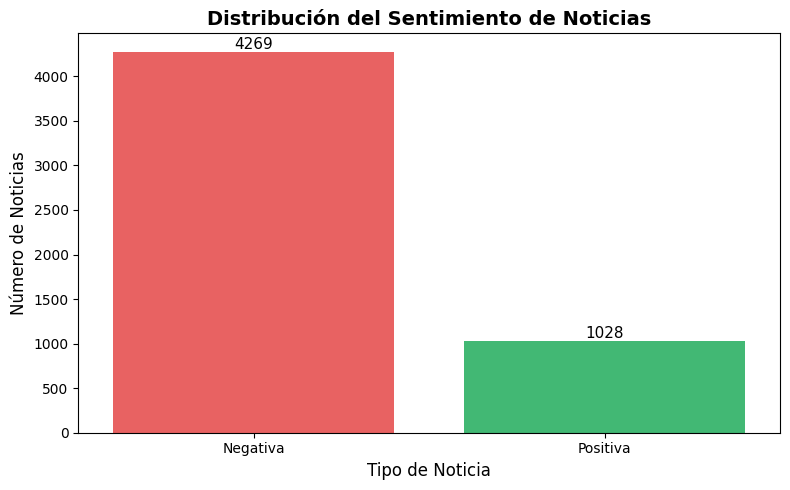

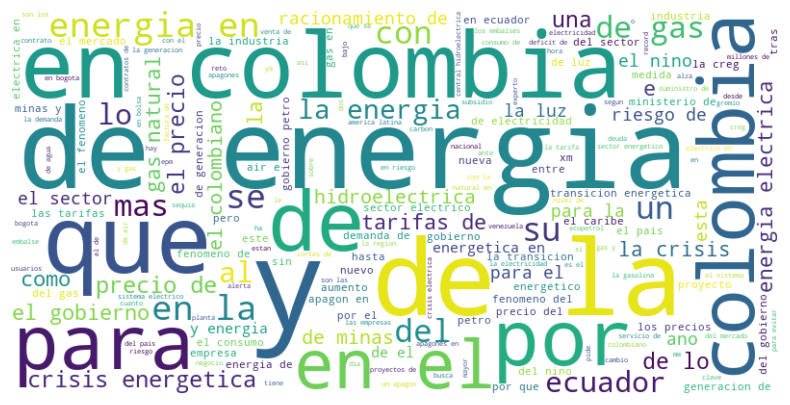

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud  # <-- La 'W' y 'C' mayúsculas son la clase, no el módulo

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x='Tipo_noticia',
    palette={'Negativa': '#ff4b4b', 'Positiva': '#2ecc71'}
)

# Títulos
plt.title('Distribución del Sentimiento de Noticias',
          fontsize=14, fontweight='bold')

# Etiquetas
plt.xlabel('Tipo de Noticia', fontsize=12)
plt.ylabel('Número de Noticias', fontsize=12)

# Agregar valores encima de cada barra
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

# 2. WordCloud (Si aquí fue el error)
textos_negativos = " ".join(df[df['Tipo_noticia'] == 'Negativa']['Titulo_norm'])

# CORRECTO: WordCloud() es la clase dentro del módulo wordcloud
wc = WordCloud(width=800, height=400, background_color='white').generate(textos_negativos)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

/var/folders/h_/y4vb90l51t3_fzy9kk_5w0y40000gn/T/ipykernel_4507/3634668905.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sent_time = df.groupby(['Fecha','Tipo_noticia']).size().unstack(fill_value=0)


<Axes: xlabel='Fecha'>

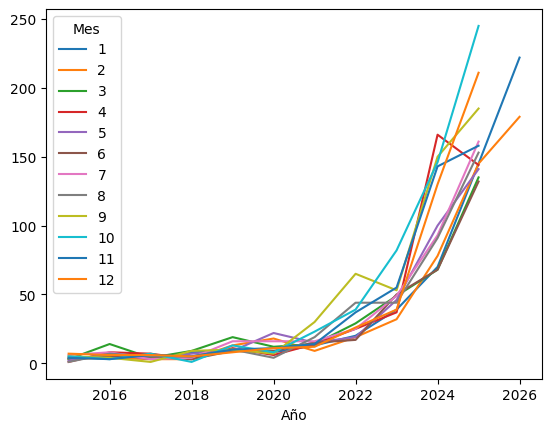

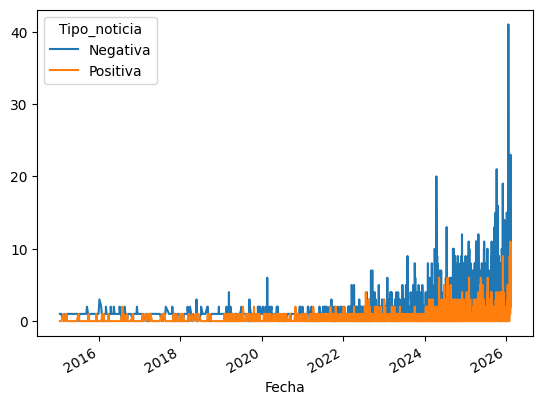

In [47]:
df.groupby(['Año','Mes']).size().unstack().plot()
sent_time = df.groupby(['Fecha','Tipo_noticia']).size().unstack(fill_value=0)
sent_time.plot()


/var/folders/h_/y4vb90l51t3_fzy9kk_5w0y40000gn/T/ipykernel_4507/3845296985.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['YearMonth','Tipo_noticia'])


<Figure size 640x480 with 0 Axes>

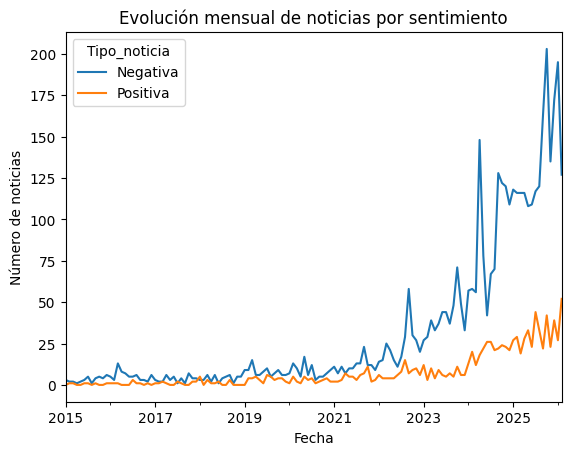

In [48]:
#Agrupación por mes
df['Fecha'] = pd.to_datetime(df['Fecha'])
df = df.sort_values('Fecha')

df['YearMonth'] = df['Fecha'].dt.to_period('M')

# Conteo Mensual por noticias
sent_month = (
    df.groupby(['YearMonth','Tipo_noticia'])
      .size()
      .unstack(fill_value=0)
)

sent_month.index = sent_month.index.to_timestamp()
#Gráfico
plt.figure()
sent_month.plot()
plt.title('Evolución mensual de noticias por sentimiento')
plt.xlabel('Fecha')
plt.ylabel('Número de noticias')
plt.show()


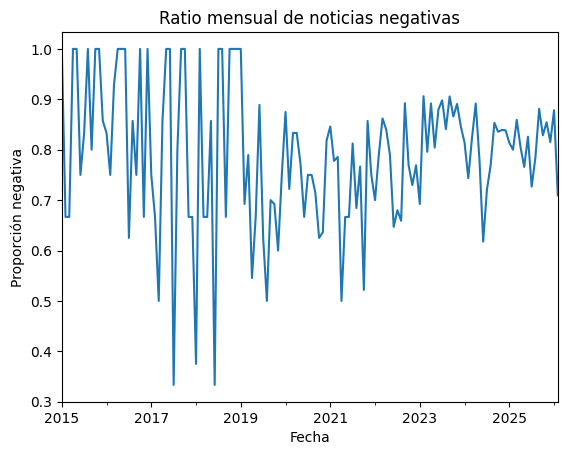

In [49]:
#Proporción mensual de negatividad
sent_month['Ratio_Neg'] = (
    sent_month['Negativa'] /
    (sent_month['Negativa'] + sent_month['Positiva'])
)
plt.figure()
sent_month['Ratio_Neg'].plot()
plt.title('Ratio mensual de noticias negativas')
plt.xlabel('Fecha')
plt.ylabel('Proporción negativa')
plt.show()



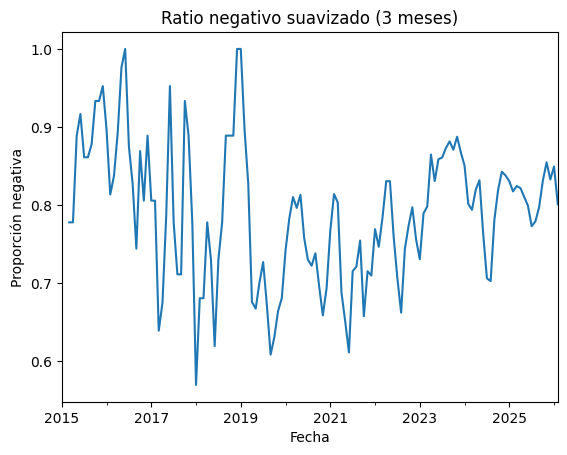

In [50]:
sent_month['Diferencial'] = (
    sent_month['Negativa'] - sent_month['Positiva']
)
sent_month['Ratio_Neg_3M'] = sent_month['Ratio_Neg'].rolling(3).mean()

plt.figure()
sent_month['Ratio_Neg_3M'].plot()
plt.title('Ratio negativo suavizado (3 meses)')
plt.xlabel('Fecha')
plt.ylabel('Proporción negativa')
plt.show()


In [51]:
df['Fuente'].value_counts()
df['Fuente'].value_counts(normalize=True)
noticias_por_fuente = df['Fuente'].value_counts()
noticias_por_fuente


Fuente
Infobae                      636
Energía Estratégica          303
LaRepublica.co               295
ELTIEMPO.COM                 280
Portafolio.co                251
                            ... 
Hitachi Energy                 1
Revista Minería & Energía      1
Revista Mercado                1
Revista La Barra               1
Teletrece                      0
Name: count, Length: 587, dtype: int64

## Análisis por fuentes ##

In [52]:
tabla_fuente = pd.crosstab(
    df['Fuente'],
    df['Tipo_noticia'],
    normalize='index'
)

tabla_fuente


Tipo_noticia,Negativa,Positiva
Fuente,,
- CIPER Chile,0.666667,0.333333
20Minutos,1.000000,0.000000
360 Radio,0.833333,0.166667
724 | noticias,1.000000,0.000000
:.Periodicovirtual.com.:,0.000000,1.000000
...,...,...
www.gub.uy,1.000000,0.000000
www.laprensa.hn,1.000000,0.000000
www.metrolibre.com,1.000000,0.000000


In [53]:
noticias_por_fuente = df['Fuente'].value_counts()

tabla_frecuencia = (
    noticias_por_fuente
    .value_counts()
    .rename_axis('Numero_Noticias')
    .reset_index(name='Cantidad_Fuentes')
    .sort_values('Numero_Noticias')
)
tabla_frecuencia


,Numero_Noticias,Cantidad_Fuentes
50,0,1
0,1,286
1,2,91
2,3,56
4,4,23
3,5,25
5,6,16
10,7,5
7,8,8
8,9,6


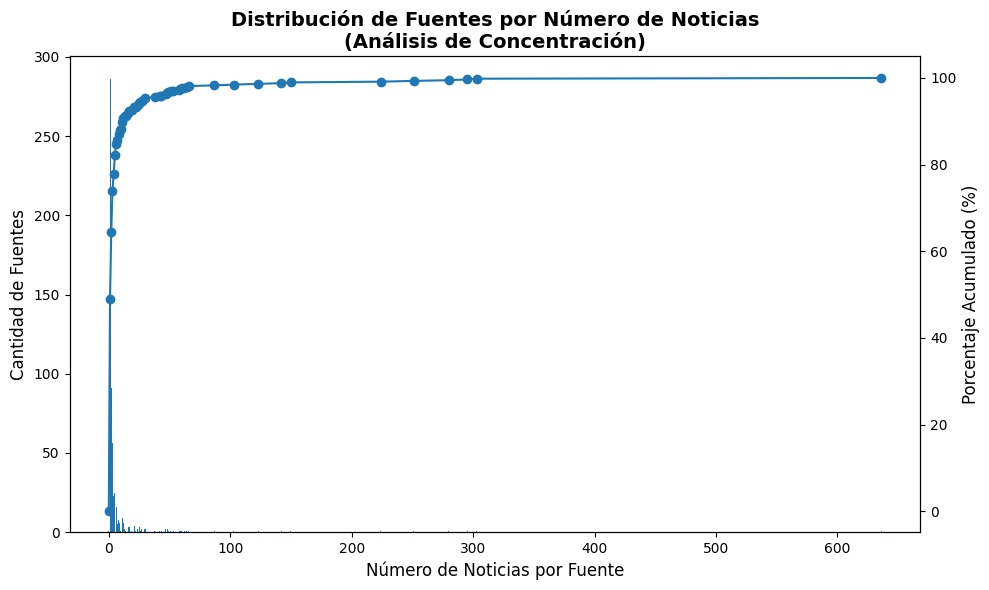

In [54]:
noticias_por_fuente = df['Fuente'].value_counts()

tabla_frecuencia = (
    noticias_por_fuente
    .value_counts()
    .rename_axis('Numero_Noticias')
    .reset_index(name='Cantidad_Fuentes')
    .sort_values('Numero_Noticias')
)

# Calcular acumulado
tabla_frecuencia['Acumulado'] = (
    tabla_frecuencia['Cantidad_Fuentes'].cumsum()
)

tabla_frecuencia['Acumulado_%'] = (
    tabla_frecuencia['Acumulado'] /
    tabla_frecuencia['Cantidad_Fuentes'].sum()
) * 100
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras
ax1.bar(
    tabla_frecuencia['Numero_Noticias'],
    tabla_frecuencia['Cantidad_Fuentes']
)

ax1.set_xlabel('Número de Noticias por Fuente', fontsize=12)
ax1.set_ylabel('Cantidad de Fuentes', fontsize=12)

# Segundo eje para acumulado
ax2 = ax1.twinx()
ax2.plot(
    tabla_frecuencia['Numero_Noticias'],
    tabla_frecuencia['Acumulado_%'],
    marker='o'
)

ax2.set_ylabel('Porcentaje Acumulado (%)', fontsize=12)

plt.title('Distribución de Fuentes por Número de Noticias\n(Análisis de Concentración)',
          fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


# MODELOS Y MINERÍA DE DATOS #

# PASO 1 #

Variable Objetivo

In [55]:
df['y'] = df['Tipo_noticia'].map({'Negativa': 1, 'Positiva': 0})


Train/Test Estratificado

In [56]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['Titulo_norm'],
    df['y'],
    test_size=0.2,
    random_state=42,
    stratify=df['y']
)


Vectorización TF-IDF

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=3
)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

# PASO 2 #

In [58]:
# Métricas
from sklearn.metrics import classification_report, roc_auc_score


# ------------------ MODELOS LINEALES ------------------ #

# MODELO 1 - Naive Bayes (Multinomial)

In [59]:
from sklearn.naive_bayes import MultinomialNB

# Esto se puede podificar el alpha
model_nb = MultinomialNB()

model_nb.fit(X_train, y_train)

pred_nb = model_nb.predict(X_test)
proba_nb = model_nb.predict_proba(X_test)[:,1]

print("NAIVE BAYES")
print(classification_report(y_test, pred_nb))
print("ROC-AUC:", roc_auc_score(y_test, proba_nb))

NAIVE BAYES
              precision    recall  f1-score   support

           0       0.97      0.50      0.66       206
           1       0.89      1.00      0.94       854

    accuracy                           0.90      1060
   macro avg       0.93      0.75      0.80      1060
weighted avg       0.91      0.90      0.89      1060

ROC-AUC: 0.9500409267638298


# MODELO 2 - Regresión Logística (Balanceada)

In [60]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)
proba_lr = model_lr.predict_proba(X_test)[:,1]

print("LOGISTIC REGRESSION")
print(classification_report(y_test, pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, proba_lr))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.91      0.89      0.90       206
           1       0.97      0.98      0.98       854

    accuracy                           0.96      1060
   macro avg       0.94      0.93      0.94      1060
weighted avg       0.96      0.96      0.96      1060

ROC-AUC: 0.9808269480002728


In [61]:
feature_names = vectorizer.get_feature_names_out()
coefs = model_lr.coef_[0]

top_neg = sorted(zip(coefs, feature_names))[:20]
top_pos = sorted(zip(coefs, feature_names))[-20:]
top_neg

[(np.float64(-9.095054169678807), 'solar'),
 (np.float64(-8.744715442628438), 'renovables'),
 (np.float64(-6.743033761800908), 'renovable'),
 (np.float64(-5.514848819634125), 'solares'),
 (np.float64(-5.2170200446874455), 'nina'),
 (np.float64(-4.974607083345547), 'bajar'),
 (np.float64(-4.927453246445815), 'la nina'),
 (np.float64(-4.4567014072425835), 'lluvias'),
 (np.float64(-4.257593050403269), 'eolica'),
 (np.float64(-3.726108729522497), 'energias renovables'),
 (np.float64(-3.2674624737927678), 'energia solar'),
 (np.float64(-3.1591151523856325), 'energia renovable'),
 (np.float64(-3.135214137046725), 'fenomeno de'),
 (np.float64(-3.098251723787931), 'energias'),
 (np.float64(-3.0529171025825748), 'baja'),
 (np.float64(-2.9268339581385083), 'energia eolica'),
 (np.float64(-2.610361249596894), 'oferta'),
 (np.float64(-2.2858334677571506), 'de la'),
 (np.float64(-2.1235771713578693), 'embalses'),
 (np.float64(-1.9760136251759761), 'para bajar')]

# MODELO 3 - Linear SVM (Balanceado)

In [62]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC no da probabilidades → lo calibramos
svm = LinearSVC(class_weight='balanced')

model_svm = CalibratedClassifierCV(svm)

model_svm.fit(X_train, y_train)

pred_svm = model_svm.predict(X_test)
proba_svm = model_svm.predict_proba(X_test)[:,1]

print("LINEAR SVM")
print(classification_report(y_test, pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, proba_svm))


LINEAR SVM
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       206
           1       0.98      0.99      0.98       854

    accuracy                           0.97      1060
   macro avg       0.96      0.95      0.95      1060
weighted avg       0.97      0.97      0.97      1060

ROC-AUC: 0.9885746117641709


# Comparación modelos lineales

In [63]:
results = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'Logistic Regression', 'Linear SVM'],
    'ROC_AUC': [
        roc_auc_score(y_test, proba_nb),
        roc_auc_score(y_test, proba_lr),
        roc_auc_score(y_test, proba_svm)
    ]
})

print(results)

                Modelo   ROC_AUC
0          Naive Bayes  0.950041
1  Logistic Regression  0.980827
2           Linear SVM  0.988575


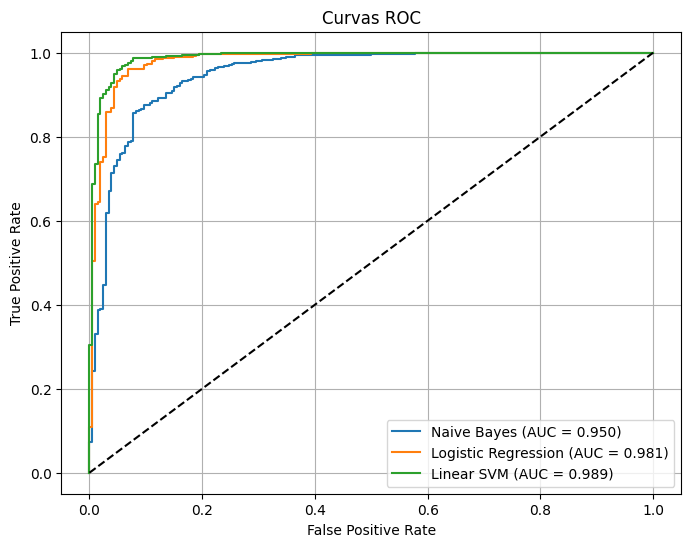

In [64]:
from sklearn.metrics import roc_curve, auc

# Probabilidades
fpr_nb, tpr_nb, _ = roc_curve(y_test, proba_nb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, proba_svm)

roc_auc_nb = auc(fpr_nb, tpr_nb)
roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8,6))

plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'Linear SVM (AUC = {roc_auc_svm:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC')
plt.legend()
plt.grid()
plt.show()


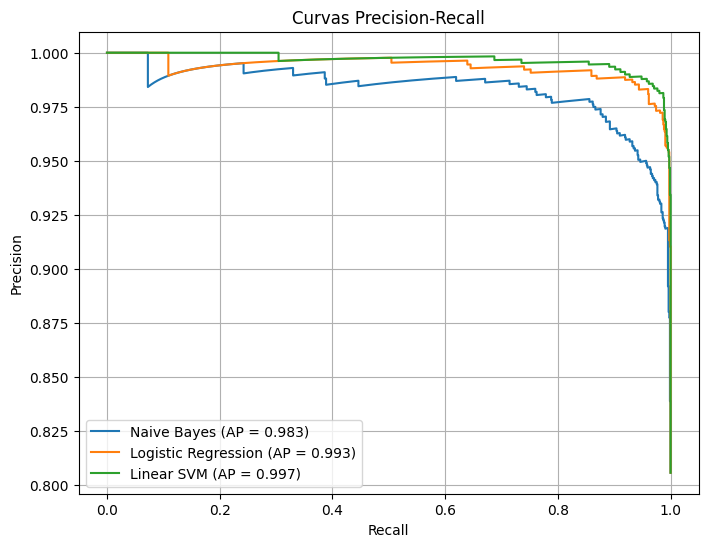

In [65]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_nb, recall_nb, _ = precision_recall_curve(y_test, proba_nb)
precision_lr, recall_lr, _ = precision_recall_curve(y_test, proba_lr)
precision_svm, recall_svm, _ = precision_recall_curve(y_test, proba_svm)

ap_nb = average_precision_score(y_test, proba_nb)
ap_lr = average_precision_score(y_test, proba_lr)
ap_svm = average_precision_score(y_test, proba_svm)

plt.figure(figsize=(8,6))

plt.plot(recall_nb, precision_nb, label=f'Naive Bayes (AP = {ap_nb:.3f})')
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP = {ap_lr:.3f})')
plt.plot(recall_svm, precision_svm, label=f'Linear SVM (AP = {ap_svm:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curvas Precision-Recall')
plt.legend()
plt.grid()
plt.show()


# ------------------ MODELOS DE ENSAMBLE ------------------ #

# Modelo 1 Random Forest

In [66]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)
proba_rf = model_rf.predict_proba(X_test)[:,1]

print("RANDOM FOREST")
print(classification_report(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, proba_rf))


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.98      0.84      0.91       206
           1       0.96      1.00      0.98       854

    accuracy                           0.97      1060
   macro avg       0.97      0.92      0.94      1060
weighted avg       0.97      0.97      0.97      1060

ROC-AUC: 0.9826601259634843


# Modelo 2 GRADIENT BOOSTING

In [67]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_gb.fit(X_train.toarray(), y_train)

pred_gb = model_gb.predict(X_test.toarray())
proba_gb = model_gb.predict_proba(X_test.toarray())[:,1]

print("GRADIENT BOOSTING")
print(classification_report(y_test, pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, proba_gb))


GRADIENT BOOSTING
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       206
           1       0.98      0.99      0.99       854

    accuracy                           0.98      1060
   macro avg       0.97      0.96      0.96      1060
weighted avg       0.98      0.98      0.98      1060

ROC-AUC: 0.981662536095132


# Modelo 3 XGBOOST

In [68]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)
proba_xgb = model_xgb.predict_proba(X_test)[:,1]

print("XGBOOST")
print(classification_report(y_test, pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, proba_xgb))


XGBOOST
              precision    recall  f1-score   support

           0       0.96      0.88      0.92       206
           1       0.97      0.99      0.98       854

    accuracy                           0.97      1060
   macro avg       0.97      0.94      0.95      1060
weighted avg       0.97      0.97      0.97      1060

ROC-AUC: 0.9802642049976127


# ------------------ RED NEURONAL ------------------ #

In [69]:
from sklearn.neural_network import MLPClassifier

model_mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    activation='relu',
    max_iter=20,
    early_stopping=True,
    random_state=42
)

model_mlp.fit(X_train, y_train)

pred_mlp = model_mlp.predict(X_test)
proba_mlp = model_mlp.predict_proba(X_test)[:,1]

print("MLP")
print(classification_report(y_test, pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, proba_mlp))


MLP
              precision    recall  f1-score   support

           0       0.90      0.75      0.82       206
           1       0.94      0.98      0.96       854

    accuracy                           0.93      1060
   macro avg       0.92      0.86      0.89      1060
weighted avg       0.93      0.93      0.93      1060

ROC-AUC: 0.9560264659739433


/opt/anaconda3/envs/integrador/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


# Comparación modelos de ensamble

In [70]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(name, y_test, pred, proba):
    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1_clase_0": f1_score(y_test, pred, pos_label=0),
        "F1_clase_1": f1_score(y_test, pred, pos_label=1),
        "F1_macro": f1_score(y_test, pred, average='macro'),
        "F1_weighted": f1_score(y_test, pred, average='weighted'),
        "ROC_AUC": roc_auc_score(y_test, proba)
    }
results_level2 = []

results_level2.append(evaluate_model("Random Forest", y_test, pred_rf, proba_rf))
results_level2.append(evaluate_model("Gradient Boosting", y_test, pred_gb, proba_gb))
results_level2.append(evaluate_model("XGBoost", y_test, pred_xgb, proba_xgb))
results_level2.append(evaluate_model("MLP", y_test, pred_mlp, proba_mlp))
results_level2.append(evaluate_model("Naive Bayes", y_test, pred_nb, proba_nb))
results_level2.append(evaluate_model("Logistic Regression", y_test, pred_lr, proba_lr))
results_level2.append(evaluate_model("Linear SVM", y_test, pred_svm, proba_svm))

import pandas as pd
results_level2_df = pd.DataFrame(results_level2)

results_level2_df


,Modelo,Accuracy,F1_clase_0,F1_clase_1,F1_macro,F1_weighted,ROC_AUC
0,Random Forest,0.966981,0.908616,0.979850,0.944233,0.966007,0.982660
1,Gradient Boosting,0.978302,0.942928,0.986605,0.964766,0.978116,0.981663
2,XGBoost,0.970755,0.921519,0.982029,0.951774,0.970269,0.980264
3,MLP,0.934906,0.816976,0.960413,0.888695,0.932538,0.956026
4,Naive Bayes,0.900000,0.660256,0.941372,0.800814,0.886740,0.950041
5,Logistic Regression,0.960377,0.897059,0.975467,0.936263,0.960229,0.980827
6,Linear SVM,0.971698,0.925373,0.982538,0.953955,0.971428,0.988575


In [71]:
# Escoger el mejor modelo según el F1_WEIGHTED
best_model = results_level2_df.sort_values('F1_weighted', ascending=False).iloc[0]
print("Mejor modelo según F1_weighted:")
print(best_model)

# Entrenar y guardar el mejor modelo
if best_model['Modelo'] == 'Random Forest':
    final_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
elif best_model['Modelo'] == 'Gradient Boosting':
    final_model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
elif best_model['Modelo'] == 'XGBoost':
    final_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
elif best_model['Modelo'] == 'MLP':
    final_model = MLPClassifier(
        hidden_layer_sizes=(128,64),
        activation='relu',
        max_iter=20,
        early_stopping=True,
        random_state=42
    )
elif best_model['Modelo'] == 'Naive Bayes':
    final_model = MultinomialNB()
elif best_model['Modelo'] == 'Logistic Regression':
    final_model = LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    )
elif best_model['Modelo'] == 'Linear SVM':
    svm = LinearSVC(class_weight='balanced')
    final_model = CalibratedClassifierCV(svm)
else:
    raise ValueError("Modelo no reconocido")

X_full = vectorizer.fit_transform(df['Titulo_norm'])
y_full = df['y']
final_model.fit(X_full, y_full)

# Guardar el vectorizador para uso futuro
joblib.dump(vectorizer, "vectorizer.joblib")

# Guardar el modelo entrenado
joblib.dump(final_model, "news_model.joblib")

Mejor modelo según F1_weighted:
Modelo         Gradient Boosting
Accuracy                0.978302
F1_clase_0              0.942928
F1_clase_1              0.986605
F1_macro                0.964766
F1_weighted             0.978116
ROC_AUC                 0.981663
Name: 1, dtype: object


['news_model.joblib']

In [74]:
# Agregar probabilidades al DataFrame original
df['Tipo_noticia'] = final_model.predict_proba(X_full)[:,1]
cols_keep = [
    "Titulo", "Fuente", "Fecha", "Hora", "url", "Titulo_norm", "Tipo_noticia"
]
df_final = df[cols_keep]
df_final.to_csv("datos_NOTICIAS.csv", index=False)